In [1]:
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from utils.evaluation import evaluate_pipeline
from utils import column_type_split, feature_importance_df
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [2]:
df = pd.read_csv("../data/train_clear.csv")

In [3]:
target = "Liver_Disease_Type"
X = df.drop(columns=[target])
y = df[target]

In [4]:
columns = column_type_split(X)

In [5]:
pipeline = Pipeline(
    [
        (
            "preprocess",
            ColumnTransformer(
                [
                    ("ohe", OneHotEncoder(drop="first"), columns.categorical),
                ],
                remainder="passthrough",
            ),
        ),
        ("logistic", LogisticRegression(max_iter=200)),
    ]
)

c:\Users\Yanovich\Documents\Projects\Cats\table_analysis\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Yanovich\Documents\Projects\Cats\table_analysis\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
 

Модель LogisticRegression
F1-macro: 0.616 ± 0.015
F1-weighted: 0.716 ± 0.010


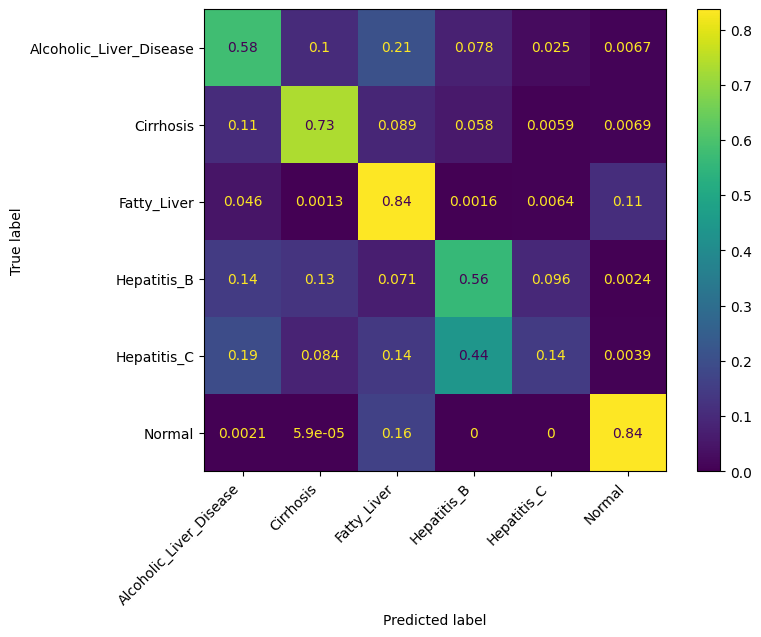

In [6]:
evaluate_pipeline(pipeline, X, y)

Из за регуляризации l2 (по умолчанию в LogisticRegression) модель сильно штрафует признаки с маленькими значениями и большими весами и почти не штрафует большие значения с маленькими весами, не давая сойтись в глобальный минимум

In [7]:
pipeline_no_l2 = Pipeline(
    [
        (
            "preprocess",
            ColumnTransformer(
                [
                    ("ohe", OneHotEncoder(drop="first"), columns.categorical),
                ],
                remainder="passthrough",
            ),
        ),
        ("logistic", LogisticRegression(C=np.inf, max_iter=200)),
    ]
)

c:\Users\Yanovich\Documents\Projects\Cats\table_analysis\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\Users\Yanovich\Documents\Projects\Cats\table_analysis\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Yanovich\Documents\Projects\Cats\table_analysis\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will 

Модель LogisticRegression
F1-macro: 0.613 ± 0.015
F1-weighted: 0.710 ± 0.012


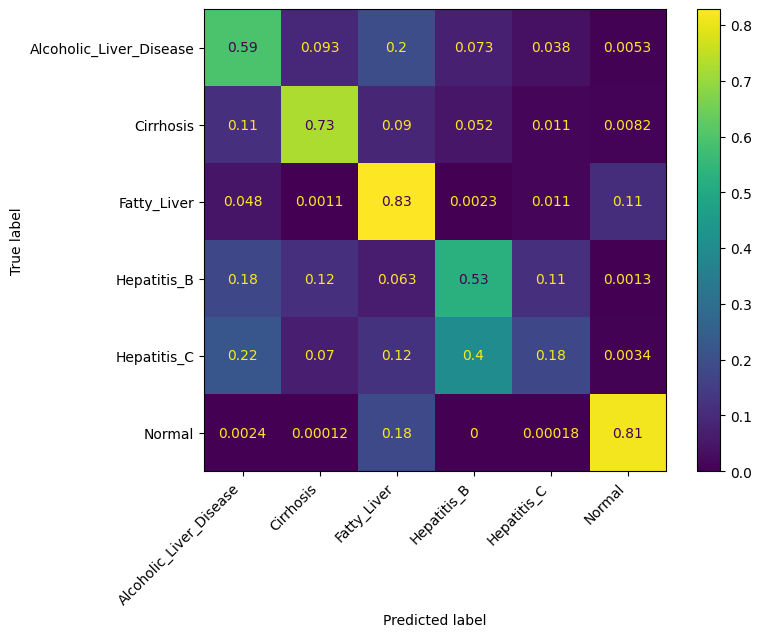

In [8]:
evaluate_pipeline(pipeline_no_l2, X, y)

Однако отключение регуляризации дает более низкую точность (на уровне погрешности, но все же). Это происходит из-за того, что модель переобучается на локальном шуме, а регуляризация, даже некачественная, все равно улучшала обобщающую способность

Для настоящего решения проблемы необходимо использовать масштабирование признаков

In [9]:
pipeline_scaled = Pipeline(
    [
        (
            "preprocess",
            ColumnTransformer(
                [
                    ("ohe", OneHotEncoder(drop="first"), columns.categorical),
                    ("scaler", StandardScaler(), columns.numeric),
                ],
                remainder="passthrough",
            ),
        ),
        ("logistic", LogisticRegression(max_iter=200)),
    ]
)

Модель LogisticRegression
F1-macro: 0.748 ± 0.004
F1-weighted: 0.817 ± 0.004


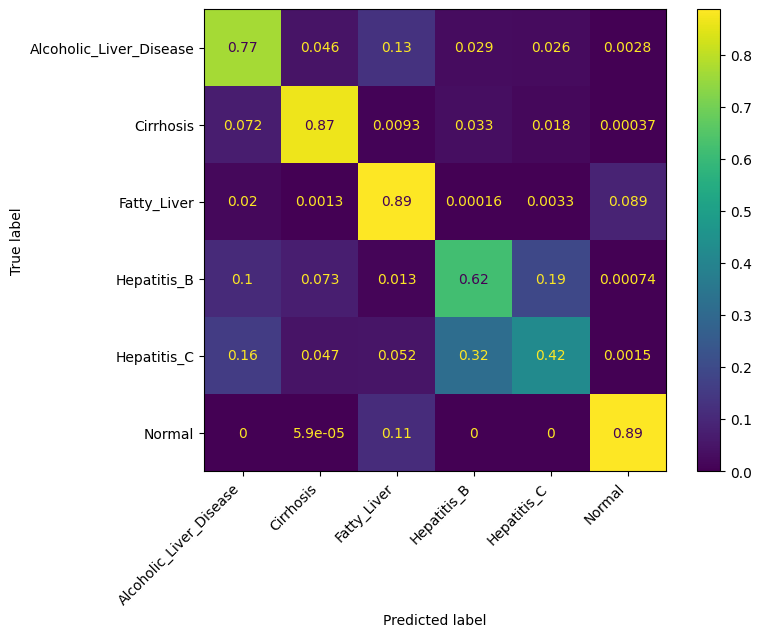

In [10]:
coefs = evaluate_pipeline(pipeline_scaled, X, y, additional="coef_")

Модель с масштабированными признаками дала высокую точность

In [11]:
feature_importance = np.array(coefs).mean(axis=0)
names = pipeline_scaled.named_steps["preprocess"].get_feature_names_out()

In [13]:
feature_importance_df(feature_importance, names, use_abs=True).head(10)

,feature,importance
27,scaler__AST,1.980638
33,remainder__Sym_Jaundice,1.888333
28,scaler__Bilirubin,1.791387
26,scaler__ALT,1.524657
36,remainder__Sym_Ascites,1.074676
35,remainder__Sym_Itching,0.946997
39,remainder__Comorb_Diabetes,0.852603
37,remainder__Sym_Dark_Urine,0.811645
32,remainder__Sym_Fatigue,0.712648
41,remainder__Comorb_Genetic_History,0.611163


Среднее по абсолютным значениям коэффициентов: для большинства болезней печени эти признаки давали существенный вклад в предсказание. Наибольшую важность имеют ферменты и симптомы